In [1]:
# 26.08.2026 - JEDEN dedykowany watek: wyjasnienie "wyblakłych" stacji z
# `20260822f.ipynb` (Homola, spotkanie 24.08, ask #5 - patrz
# project_homola_review_feedback.md w pamieci Claude'a): na globalnej
# heatmapie sily efektu (22 stacje x os czasu, kolor=-log10(PPDF)) niektore
# stacje wygladaja calkowicie plasko/ciemno - nigdzie nie osiagaja silnego
# efektu, mimo obecnosci danych. Dlaczego?
#
# Trzy kandydujace wyjasnienia testowane rownolegle, wszystkie na JUZ
# ISTNIEJACYCH danych (zero nowych obliczen NMDB/MC):
#   (A) JAKOSC DANYCH - stacja z zaklamana/zamrozona/zerowa "jakoscia"
#       (patrz 20260826b.ipynb: MCRL, NANM wykluczone; mxco/jung1/invk pod
#       obserwacja) nie moze pokazac realnego efektu, bo dane wejsciowe sa
#       zle.
#   (B) DLUGOSC HISTORII / LICZBA NIEZALEZNYCH PROB - stacja z krotsza
#       historia ma mniej kandydatow t0, wiec czysto losowo ma mniejsza
#       szanse "trafic" bardzo niskie PPDF (maksimum z N losowych probek
#       rosnie z N) - to bylby efekt statystyczny (look-elsewhere), nie
#       jakosc danych. Wiaze sie z uwaga z przegladu Opusa (24.08) o
#       liczeniu "trafien" bez poprawki na k_eff/liczbe prob - patrz
#       project_cycle_to_cycle_map.md.
#   (C) REALNA FIZYKA - stacja moze byc po prostu mniej czula (np. wysoki
#       cutoff rigidity, nizsza szerokosc geomagnetyczna) - wtedy "wyblakniecie"
#       jest prawdziwym, nie artefaktycznym wynikiem.
#
# UWAGA O ZAKRESIE: ten notebook CELOWO uzywa PELNEGO zestawu 22 stacji
# (w tym MCRL i NANM) - bo pytanie brzmi wprost "dlaczego TE stacje na TEJ
# heatmapie wygladaly tak, jak wygladaly", wiec trzeba je tu zostawic, mimo
# ze zostaly wykluczone z biezacej/przyszlej analizy glownej (patrz
# project_station_data_quality.md).
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

RESULTS_DIR = "../results"
HOMOLA_LOG10_PPDF_BENCHMARK = -8

# Ta sama lista stacji i to samo zrodlo danych (cycle_scan_*.csv,
# P_days=3350, d=5 - "wersja z najwiecej trafien", dokladnie ta sama
# kombinacja co WERSJA 1 w 20260822f.ipynb) co oryginalna heatmapa, zeby
# wyjasnienie dotyczylo TEGO KONKRETNEGO obrazka, ktory widzial Homola.
STATION_NAMES = sorted(
    ["mosc", "oulu", "athn", "hrms", "sopb", "thul", "lmks", "apty", "jung1",
     "sopo", "fsmt", "jung", "newk", "pwnk", "mxco", "nain", "tera", "invk",
     "aatb", "psnm", "nanm", "mcrl"],
    key=len, reverse=True,
)
P_DAYS_TARGET = 3350
D_TARGET = 5
FILENAME_RE = re.compile(r"^(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)$")


def parse_result_filename(path):
    base = os.path.basename(path)
    if not (base.startswith("cycle_scan_") and base.endswith(".csv")):
        return None
    rest = base[len("cycle_scan_"):-len(".csv")]
    station = next((s for s in STATION_NAMES if rest.startswith(s + "_")), None)
    if station is None:
        return None
    m = FILENAME_RE.match(rest[len(station) + 1:])
    if not m:
        return None
    return dict(station=station, P_days=int(m["Pdays"]), d=int(m["d"]))


frames = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_result_filename(path)
    if meta is None or meta["P_days"] != P_DAYS_TARGET or meta["d"] != D_TARGET:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    frames.append(df)

all_candidates = pd.concat(frames, ignore_index=True)
print(f"Wczytano {len(all_candidates)} wierszy (P_days={P_DAYS_TARGET}, d={D_TARGET}) z {len(frames)} stacji")

Wczytano 295430 wierszy (P_days=3350, d=5) z 86 stacji


In [2]:
# KROK 2: dla kazdej stacji - metryka "sily piku" widocznej na heatmapie
# (dokladnie ta wielkosc, ktora tam jest kolorem): max i p95 z -log10(PPDF)
# po calej WLASNEJ historii kandydatow t0, plus frakcja kandydatow bijacych
# benchmark Homoli (log10 PPDF < -8) i liczba kandydatow (do testu
# wyjasnienia B - dlugosc historii).
rows = []
for station, g in all_candidates.groupby("station"):
    with np.errstate(divide="ignore"):
        neglog = -np.log10(np.clip(g["PPDF"].to_numpy(dtype=float), 1e-300, None))
    rows.append(dict(
        station=station,
        n_candidates=len(g),
        max_neglog10_ppdf=np.nanmax(neglog),
        p95_neglog10_ppdf=np.nanpercentile(neglog, 95),
        median_neglog10_ppdf=np.nanmedian(neglog),
        frac_above_benchmark=float((neglog > -HOMOLA_LOG10_PPDF_BENCHMARK).mean()),
    ))

peak_strength = pd.DataFrame(rows).sort_values("max_neglog10_ppdf", ascending=False)
peak_strength.to_csv(f"{RESULTS_DIR}/station_peak_strength.csv", index=False)
pd.set_option("display.width", 160)
print(peak_strength.to_string(index=False))

station  n_candidates  max_neglog10_ppdf  p95_neglog10_ppdf  median_neglog10_ppdf  frac_above_benchmark
   athn          8840          12.788865           8.165778              2.118836              0.055430
   hrms         18599          11.351104           6.953918              2.111757              0.024679
   lmks         15761          10.673055           4.454017              1.908679              0.010279
   newk         18599           9.807806           5.534117              1.982631              0.003871
   aatb         18599           9.496113           5.504035              1.908679              0.003441
   invk          9154           8.853391           5.705204              1.956222              0.005134
   thul         18599           8.788242           5.109094              1.956915              0.002097
   oulu         18599           8.592556           5.248098              2.057073              0.002796
   jung         18599           8.399602           5.681137     

In [3]:
# KROK 3: dolaczenie wynikow jakosci danych z 20260826b.ipynb (te same 22
# stacje, sprzed decyzji o wykluczeniu MCRL/NANM) - kompletnosc, zgodnosc z
# siecia, integralnosc surowych danych.
completeness = pd.read_csv(f"{RESULTS_DIR}/station_data_completeness.csv")
network_agreement = pd.read_csv(f"{RESULTS_DIR}/station_network_agreement.csv")
integrity = pd.read_csv(f"{RESULTS_DIR}/station_data_integrity.csv")

combined = (
    peak_strength
    .merge(completeness[["station", "completeness_pct", "span_years"]], on="station", how="left")
    .merge(network_agreement[["station", "median_corr_with_others"]], on="station", how="left")
    .merge(integrity[["station", "n_nonpositive", "longest_stuck_run_readings"]], on="station", how="left")
)
combined["excluded"] = combined["station"].isin(["mcrl", "nanm"])
combined["caution"] = combined["station"].isin(["mxco", "jung1", "invk"])
combined.to_csv(f"{RESULTS_DIR}/station_faded_explanation.csv", index=False)
print(combined.sort_values("max_neglog10_ppdf").to_string(index=False))

station  n_candidates  max_neglog10_ppdf  p95_neglog10_ppdf  median_neglog10_ppdf  frac_above_benchmark  completeness_pct  span_years  median_corr_with_others  n_nonpositive  longest_stuck_run_readings  excluded  caution
   mcrl          5966           4.181743           3.330710              1.622366              0.000000         14.659418   70.880903                 0.078100            285                         117      True    False
  jung1         14268           4.588346           3.152065              1.627652              0.000000         98.456537   39.999316                 0.557319              0                           0     False     True
   nanm         10249           5.741876           3.891385              1.822791              0.000000         93.879815   28.998631                -0.006696              0                         128      True    False
   tera         18599           6.531976           3.813661              1.653665              0.000000         83.2

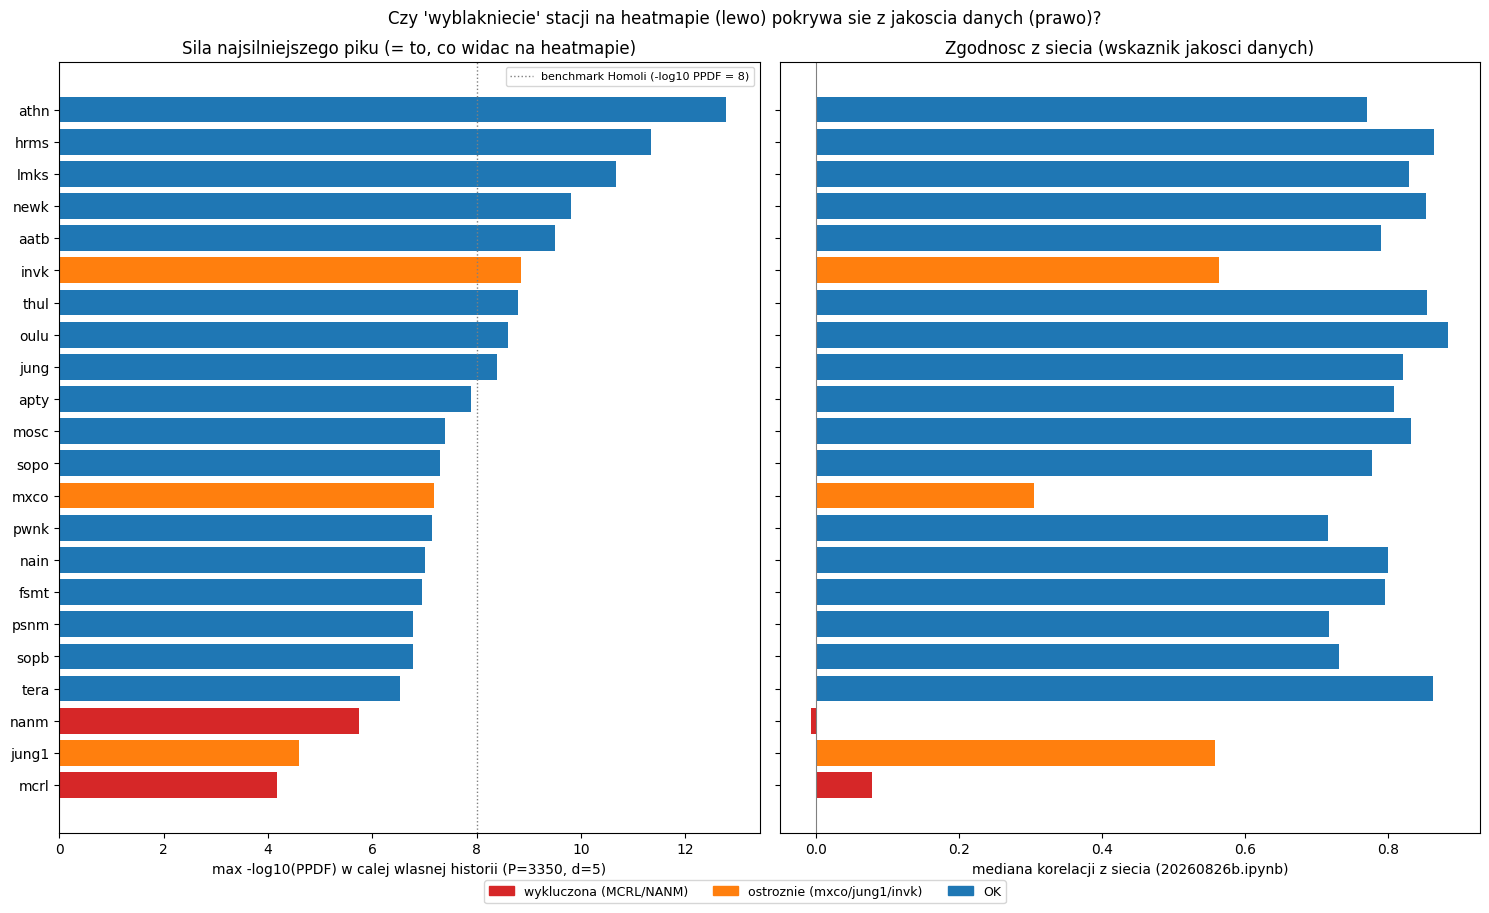

In [4]:
# KROK 4: dwa panele obok siebie, TA SAMA kolejnosc stacji (wg sily piku,
# rosnaco) - lewy = sila piku (to co widac jako "wyblakniecie" na
# heatmapie), prawy = zgodnosc z siecia (jakosc danych z 20260826b.ipynb).
# Jesli wyblakle stacje (dol lewego panelu) to te same co nisko w prawym
# panelu - jakosc danych tlumaczy wyblakniecie. Kolor = status z decyzji
# 26.08 (czerwony=wykluczona, pomaranczowy=ostroznie, niebieski=OK).
def status_color(row):
    if row["excluded"]:
        return "tab:red"
    if row["caution"]:
        return "tab:orange"
    return "tab:blue"


order = combined.sort_values("max_neglog10_ppdf", ascending=True)
colors = order.apply(status_color, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 9), sharey=True)
axes[0].barh(order["station"], order["max_neglog10_ppdf"], color=colors)
axes[0].axvline(HOMOLA_LOG10_PPDF_BENCHMARK * -1, color="gray", ls=":", lw=1,
                 label="benchmark Homoli (-log10 PPDF = 8)")
axes[0].set_xlabel("max -log10(PPDF) w calej wlasnej historii (P=3350, d=5)")
axes[0].set_title("Sila najsilniejszego piku (= to, co widac na heatmapie)")
axes[0].legend(fontsize=8)

axes[1].barh(order["station"], order["median_corr_with_others"], color=colors)
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_xlabel("mediana korelacji z siecia (20260826b.ipynb)")
axes[1].set_title("Zgodnosc z siecia (wskaznik jakosci danych)")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["tab:red", "tab:orange", "tab:blue"]]
fig.legend(handles, ["wykluczona (MCRL/NANM)", "ostroznie (mxco/jung1/invk)", "OK"],
           loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Czy 'wyblakniecie' stacji na heatmapie (lewo) pokrywa sie z jakoscia danych (prawo)?")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_faded_vs_quality.png", dpi=120, bbox_inches="tight")
plt.show()

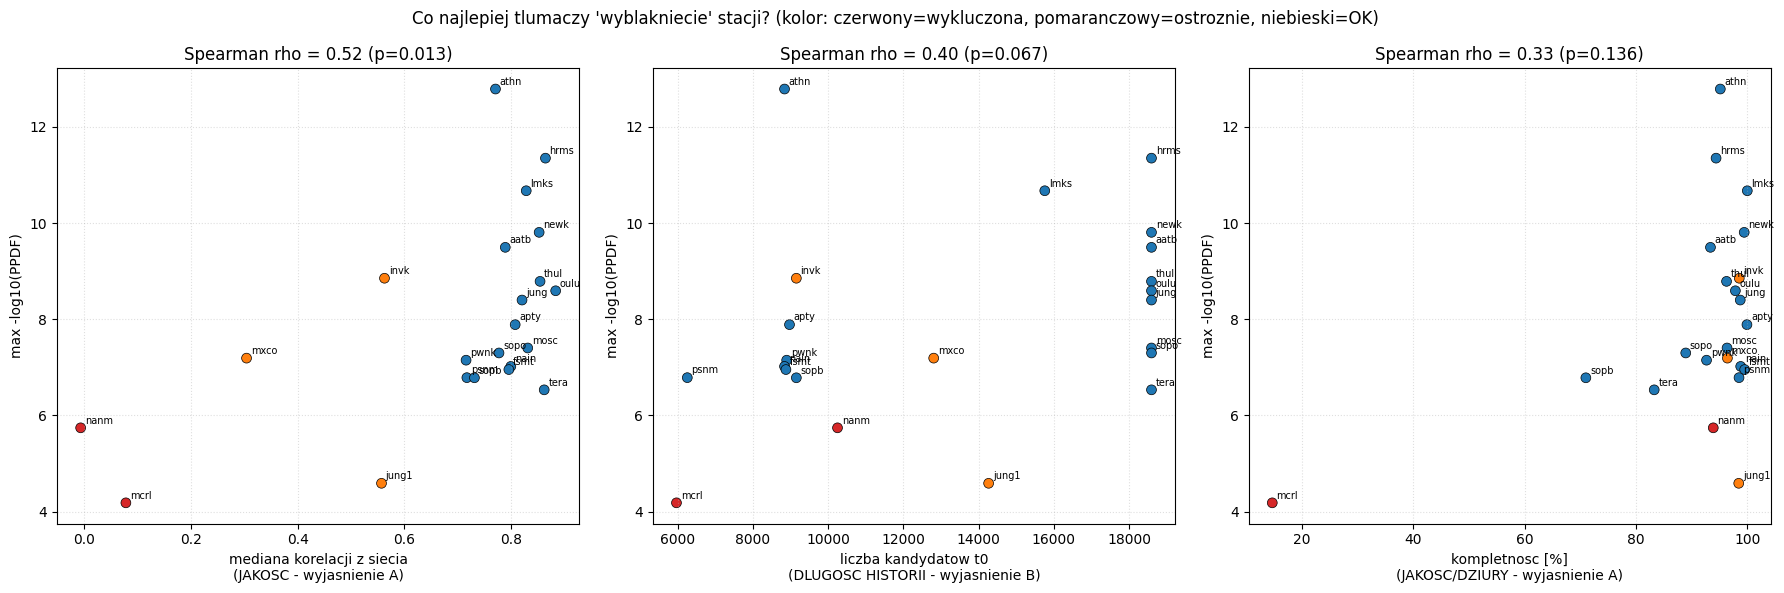

In [5]:
# KROK 5: rozstrzygniecie miedzy trzema wyjasnieniami z naglowka (A jakosc
# danych, B dlugosc historii/liczba prob, C fizyka) - trzy wykresy
# rozrzutu: sila piku vs (a) zgodnosc z siecia, (b) liczba kandydatow
# (dlugosc historii), (c) kompletnosc. Spearman rho (odporne na
# nieliniowosc/pojedyncze odstajace) w tytule kazdego panelu.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x_cols = [
    ("median_corr_with_others", "mediana korelacji z siecia\n(JAKOSC - wyjasnienie A)"),
    ("n_candidates", "liczba kandydatow t0\n(DLUGOSC HISTORII - wyjasnienie B)"),
    ("completeness_pct", "kompletnosc [%]\n(JAKOSC/DZIURY - wyjasnienie A)"),
]
for ax, (xcol, xlabel) in zip(axes, x_cols):
    colors = combined.apply(status_color, axis=1)
    ax.scatter(combined[xcol], combined["max_neglog10_ppdf"], c=colors, s=50, edgecolor="black", linewidth=0.5)
    for _, row in combined.iterrows():
        ax.annotate(row["station"], (row[xcol], row["max_neglog10_ppdf"]), fontsize=7,
                     xytext=(3, 3), textcoords="offset points")
    valid = combined[[xcol, "max_neglog10_ppdf"]].dropna()
    rho, p = spearmanr(valid[xcol], valid["max_neglog10_ppdf"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("max -log10(PPDF)")
    ax.set_title(f"Spearman rho = {rho:.2f} (p={p:.3f})")
    ax.grid(ls=":", alpha=0.4)

fig.suptitle("Co najlepiej tlumaczy 'wyblakniecie' stacji? (kolor: czerwony=wykluczona, pomaranczowy=ostroznie, niebieski=OK)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_faded_explanations_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
# PODSUMOWANIE (do dziennika 20260826.txt): obiektywnie "wyblakle" stacje =
# te, ktore NIGDY nie biją benchmarku Homoli (frac_above_benchmark == 0) w
# calej swojej historii, P=3350/d=5 - i rozbicie, ile z nich tlumaczy sie
# jakoscia danych (juz wykluczone/pod obserwacja) a ile NIE (czyli albo
# dlugosc historii, albo realna fizyka - wyjasnienia B/C).
faded = combined[combined["frac_above_benchmark"] == 0].sort_values("max_neglog10_ppdf")
print(f"=== Stacje, ktore NIGDY nie osiagnely benchmarku Homoli (log10 PPDF < -8), "
      f"P=3350/d=5 ({len(faded)} z {len(combined)}) ===")
print(faded[["station", "max_neglog10_ppdf", "n_candidates", "completeness_pct",
             "median_corr_with_others", "excluded", "caution"]].to_string(index=False))

explained_by_quality = faded[faded["excluded"] | faded["caution"]]
not_explained = faded[~(faded["excluded"] | faded["caution"])]
print(f"\nZ tego wytlumaczone jakoscia danych (juz wykluczone lub pod obserwacja): "
      f"{len(explained_by_quality)} - {explained_by_quality['station'].tolist()}")
print(f"NIEwytlumaczone jakoscia danych (kandydaci na wyjasnienie B: krotka historia, "
      f"lub C: realna fizyka): {len(not_explained)} - {not_explained['station'].tolist()}")
if len(not_explained):
    print("\nDla tych stacji - mediana liczby kandydatow (dlugosc historii) w calym "
          f"zestawie: {combined['n_candidates'].median():.0f}, u nich: "
          f"{not_explained['n_candidates'].median():.0f}")

print("\nUWAGA: to jest przeglad korelacyjny na juz istniejacych danych, nie dowod "
      "przyczynowosci - Spearman rho z KROK 5 pokazuje, ktore wyjasnienie (A/B/C) ma "
      "najsilniejszy zwiazek statystyczny, ale nie rozstrzyga go w 100% (np. krotka "
      "historia i słabsza jakosc moga wystepowac razem u tych samych stacji).")

=== Stacje, ktore NIGDY nie osiagnely benchmarku Homoli (log10 PPDF < -8), P=3350/d=5 (13 z 22) ===
station  max_neglog10_ppdf  n_candidates  completeness_pct  median_corr_with_others  excluded  caution
   mcrl           4.181743          5966         14.659418                 0.078100      True    False
  jung1           4.588346         14268         98.456537                 0.557319     False     True
   nanm           5.741876         10249         93.879815                -0.006696      True    False
   tera           6.531976         18599         83.270034                 0.862318     False    False
   sopb           6.782704          9154         70.991396                 0.731524     False    False
   psnm           6.785398          6254         98.506671                 0.717363     False    False
   fsmt           6.953918          8877         99.520065                 0.796069     False    False
   nain           7.019311          8840         98.807482                 0